# SVM Model Evaluation

## POC-SVM Model on small data until get the exact data

In [1]:
!pip install lime
!pip install shap

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc,
    accuracy_score
)

from lime import lime_tabular
import shap
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load and Preprocess Images
dataset_path = r'/Users/aesha/Documents/Group4/data/balanced_labeled_photos'
image_size = (64, 64)  # Resize for consistency

X = []
y = []

MAX_IMAGES_PER_CLASS = 2000  # change as needed

for label in os.listdir(dataset_path):
    label_folder = os.path.join(dataset_path, label)
    if os.path.isdir(label_folder):
        count = 0
        for img_file in os.listdir(label_folder):
            if count >= MAX_IMAGES_PER_CLASS:
                break
            img_path = os.path.join(label_folder, img_file)
            try:
                with Image.open(img_path) as img:
                    img = img.convert("RGB")
                    img = img.resize(image_size)
                    img_array = np.array(img).flatten()
                    X.append(img_array)
                    y.append(label)
                    count += 1
            except Exception as e:
                print(f"Skipped {img_file} due to error: {e}")

In [4]:
# Convert to NumPy Arrays + Encode Labels
X = np.array(X)
y = np.array(y)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_

In [5]:
# Train-Test Split + Scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# PCA
pca = PCA(n_components=1500)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [7]:
# Train SVM Model
clf = SVC(kernel='rbf', probability=True, random_state=42)
clf.fit(X_train_pca, y_train)

SVC(probability=True, random_state=42)

In [8]:
# Evaluate Model
y_pred = clf.predict(X_test_pca)
y_prob = clf.predict_proba(X_test_pca)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=classes))

Accuracy: 0.6985
              precision    recall  f1-score   support

       drink       0.61      0.59      0.60       400
        food       0.80      0.75      0.77       400
      inside       0.68      0.81      0.74       400
        menu       0.73      0.67      0.70       400
     outside       0.68      0.67      0.68       400

    accuracy                           0.70      2000
   macro avg       0.70      0.70      0.70      2000
weighted avg       0.70      0.70      0.70      2000



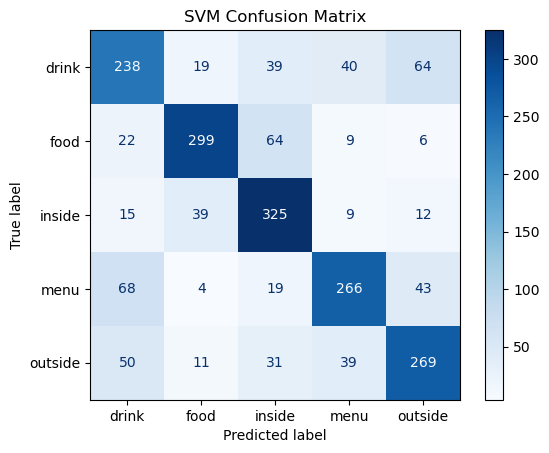

In [9]:
# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("SVM Confusion Matrix")
plt.show()

In [10]:
# AUC Score
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))
auc_score = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')
print("AUC Score:", auc_score)

AUC Score: 0.9215140625


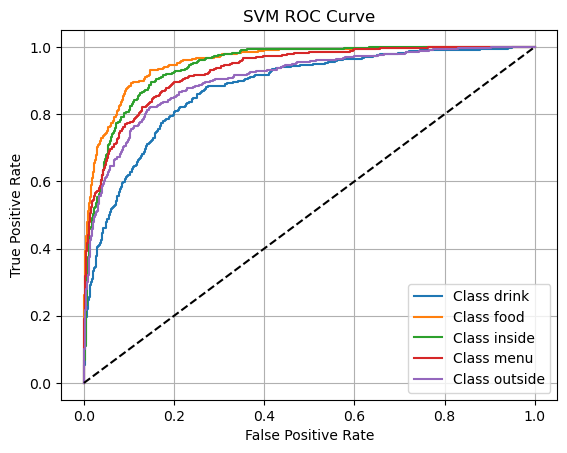

In [11]:
# ROC Curve
fpr, tpr = {}, {}
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr[i], tpr[i], label=f'Class {classes[i]}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Hyperparameter Tuning
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}
grid = GridSearchCV(SVC(probability=True), param_grid, cv=3, scoring='roc_auc_ovr')
grid.fit(X_train_pca, y_train)

print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_pca)
cm_best = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=classes).plot()
plt.title("Tuned SVM Confusion Matrix")
plt.show()

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
# LIME Explanation
explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_pca,
    feature_names=[f'PC{i+1}' for i in range(X_train_pca.shape[1])],
    class_names=classes.tolist(),
    discretize_continuous=True
)
exp = explainer.explain_instance(X_test_pca[0], clf.predict_proba, num_features=10)
exp.show_in_notebook(show_table=True)

In [ ]:
# SHAP Explanation (CPU Safe)
shap_explainer = shap.KernelExplainer(clf.predict_proba, X_train_pca[:50])
shap_values = shap_explainer.shap_values(X_test_pca[:5])
shap.summary_plot(shap_values, X_test_pca[:5], feature_names=[f'PC{i+1}' for i in range(X_test_pca.shape[1])])